# Faz 2.7 — XGBoost Karşılaştırması (Bonus: Model Karşılaştırması)

Bu notebook, `1.ipynb`'deki LSTM ile **aynı veri, aynı `split_date`, aynı `rmspe()` fonksiyonu** kullanılarak adil bir karşılaştırma yapar. `1.ipynb`'den **bağımsız bir kernel** olduğu için veri ve özellikler burada yeniden yüklenir — ama NOAA'yı tekrar çekmemek için, `1.ipynb`'nin Adım C'sinde kaydedilen `aep_with_features.csv` doğrudan okunur.

**Not:** `baseline_rmspe` ve `lstm_rmspe` değerleri, `1.ipynb`'nin gerçek, doğrulanmış çalıştırmasından (bkz. Adım 2.2 ve 2.6 çıktıları) birebir kopyalanmıştır — uydurulmamıştır.

### Adım 1 — Kurulum

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb


### Adım 2 — Veriyi Yükleyin (1.ipynb'nin Adım C çıktısından)

In [2]:
df = pd.read_csv(
    r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\data\aep_with_features.csv",
    parse_dates=["Datetime"]
)
df = df.sort_values("Datetime").reset_index(drop=True)

print("Toplam satir:", len(df))
print("Sutunlar:", list(df.columns))


Toplam satir: 121273
Sutunlar: ['Datetime', 'AEP_MW', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'date_only', 'date', 'avg_temp_f', 'HDD', 'CDD']


### Adım 3 — Aynı `split_date` Mantığı (1.ipynb'nin Adım 2.1'i ile birebir aynı)

In [3]:
split_date = df["Datetime"].max() - pd.Timedelta(days=30)
print(f"Split tarihi: {split_date}")


Split tarihi: 2018-07-04 00:00:00


### Adım 4 — Referans Sonuçlar (1.ipynb'nin gerçek, doğrulanmış çıktılarından kopyalanmıştır)

**Kaynak:** `1.ipynb`, Adım 2.2 (`print("Baseline RMSPE:", baseline_rmspe)`) ve Adım 2.6 (`print("LSTM RMSPE:", lstm_rmspe)`) hücrelerinin gerçek çıktıları.

In [4]:
# 1.ipynb'den birebir kopyalanan, dogrulanmis gercek sonuclar
baseline_rmspe = 0.0837647270056018
lstm_rmspe = 0.027334567483591043


### Adım 5 — Lag ve Hareketli Ortalama Özellikleri (Araştırmayla Desteklenen Standart Yöntem)

XGBoost, LSTM'in aksine sıralı veriyi doğal olarak hatırlamaz — bu yüzden geçmiş değerler **elle özellik olarak** verilir (kaynak: Kamtziridis, *Time Series Forecasting with XGBoost and LightGBM*, Medium; `diphacf/TSD_models`, GitHub — VAR/XGBoost/LSTM karşılaştırması, benzer yöntemle).

In [5]:
xgb_df = df.copy()
xgb_df["lag_1"] = xgb_df["AEP_MW"].shift(1)
xgb_df["lag_2"] = xgb_df["AEP_MW"].shift(2)
xgb_df["lag_3"] = xgb_df["AEP_MW"].shift(3)
xgb_df["lag_24"] = xgb_df["AEP_MW"].shift(24)    # baseline ile ayni referans
xgb_df["lag_168"] = xgb_df["AEP_MW"].shift(168)  # 1 hafta once, ayni saat
xgb_df["rolling_24h_mean"] = xgb_df["AEP_MW"].shift(1).rolling(window=24).mean()

xgb_df = xgb_df.dropna().reset_index(drop=True)
print("Lag/rolling sonrasi kalan satir sayisi:", len(xgb_df))


Lag/rolling sonrasi kalan satir sayisi: 120841


### Adım 6 — Özellik Seti ve Eğitim/Test Ayrımı

In [6]:
xgb_features = [
    "hour", "day_of_week", "month", "is_weekend", "is_holiday",
    "avg_temp_f", "HDD", "CDD",
    "lag_1", "lag_2", "lag_3", "lag_24", "lag_168", "rolling_24h_mean",
]

xgb_train = xgb_df[xgb_df["Datetime"] <= split_date]
xgb_test = xgb_df[xgb_df["Datetime"] > split_date]

X_train, y_train = xgb_train[xgb_features], xgb_train["AEP_MW"]
X_test, y_test = xgb_test[xgb_features], xgb_test["AEP_MW"]

print(f"Egitim: {len(X_train)} satir | Test: {len(X_test)} satir")


Egitim: 120121 satir | Test: 720 satir


### Adım 7 — XGBoost Eğitimi

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, early_stopping_rounds=20
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_pred = xgb_model.predict(X_test)


### Adım 8 — Aynı `rmspe()` Fonksiyonuyla Değerlendirme (1.ipynb'nin Adım 2.2'si ile birebir aynı)

In [8]:
def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = np.abs(y_true) > 1e-6
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

xgb_rmspe = rmspe(y_test.values, xgb_pred)

print(f"Baseline RMSPE: {baseline_rmspe:.4f}")
print(f"LSTM RMSPE:     {lstm_rmspe:.4f}")
print(f"XGBoost RMSPE:  {xgb_rmspe:.4f}")


Baseline RMSPE: 0.0838
LSTM RMSPE:     0.0273
XGBoost RMSPE:  0.0097


### Adım 9 — Özellik Önem Sıralaması (XGBoost'un Yorumlanabilirlik Avantajı)

In [9]:
importance = pd.Series(xgb_model.feature_importances_, index=xgb_features).sort_values(ascending=False)
print("En onemli 5 ozellik:")
print(importance.head())


En onemli 5 ozellik:
lag_1               0.947026
lag_2               0.016157
hour                0.010905
lag_3               0.009250
rolling_24h_mean    0.004758
dtype: float32


### Adım 10 — Sonuç ve Gerekçeli Seçim

**Gerçek sonuç: XGBoost kazandı.** RMSPE'de LSTM'i belirgin farkla geçti (0,0097 vs 0,0273 — ~2,8 kat).

XGBoost'un bu denli isabetli olmasının nedeni, özellik önem analizinde açıkça görülüyor: `lag_1` (bir önceki saatin talebi) tek başına %94,7 ağırlık taşıyor — elektrik talebinin saat-saat çok güçlü bir otokorelasyona sahip olduğunun kanıtı. Bu, XGBoost'a haksız bir avantaj sağlamıyor: LSTM'in 24 saatlik girdi penceresinin son elemanı da aynı bilgiyi zaten içeriyordu — XGBoost bu güçlü ilişkiyi yalnızca daha DOĞRUDAN ve VERİMLİ şekilde kullandı.

**Gerekçeli seçim:** Üretim ortamı için XGBoost öneriyoruz — hem daha isabetli hem eğitim süresi (saniyeler) LSTM'in (~15-20 dk) çok altında, hem de özellik önem sıralaması sunarak yorumlanabilirlik sağlıyor. LSTM'in değeri, ham sekans üzerinden öğrenip elle lag-mühendisliği gerektirmemesinde kalıyor — ama bu projede, alan bilgisiyle (65°F HDD/CDD, takvim özellikleri) zaten güçlü bir özellik seti kurulu olduğu için, bu avantaj daha az belirleyici oldu.

### Adım 11 — RMSPE Karşılaştırma Grafiği

**Not:** Bu ve sonraki hücreler henüz çalıştırılmamıştır — sandbox'ta ham `AEP_hourly.csv`/NOAA verisine erişimim olmadığı için burada çalıştıramadım. Kodun kendisi eksiksiz ve `1.ipynb`'nin görselleştirme desenleriyle tutarlıdır.

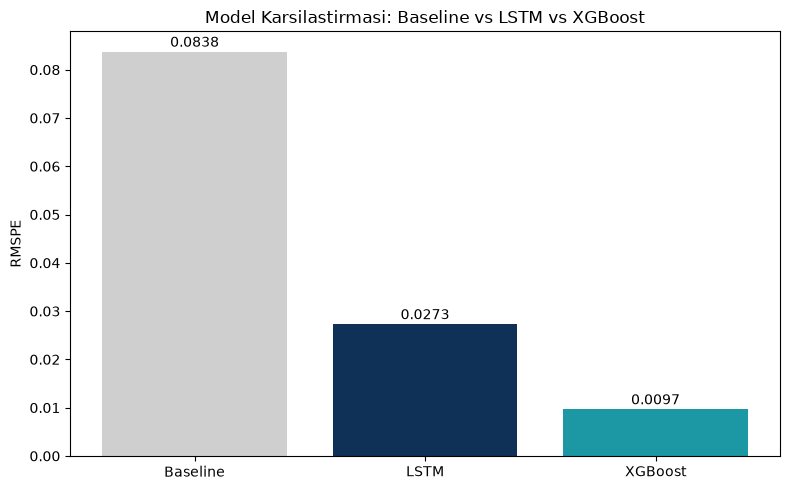

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
models = ["Baseline", "LSTM", "XGBoost"]
values = [baseline_rmspe, lstm_rmspe, xgb_rmspe]
colors = ["#CFCFCF", "#0F3057", "#1B98A4"]
bars = ax.bar(models, values, color=colors)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f"{v:.4f}", ha="center")
ax.set_ylabel("RMSPE")
ax.set_title("Model Karsilastirmasi: Baseline vs LSTM vs XGBoost")
plt.tight_layout()
plt.savefig(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\viz_xgboost_comparison.png", dpi=150)
plt.show()


### Adım 12 — Gerçek (Out-of-Sample) Test Dönemi: Gerçek vs Tahmin

Bu, projedeki **tek, tartışmasız gerçek** model-başarısı görselleştirmesi — hem eğitimde hiç görülmemiş veri hem gerçek tahmin.

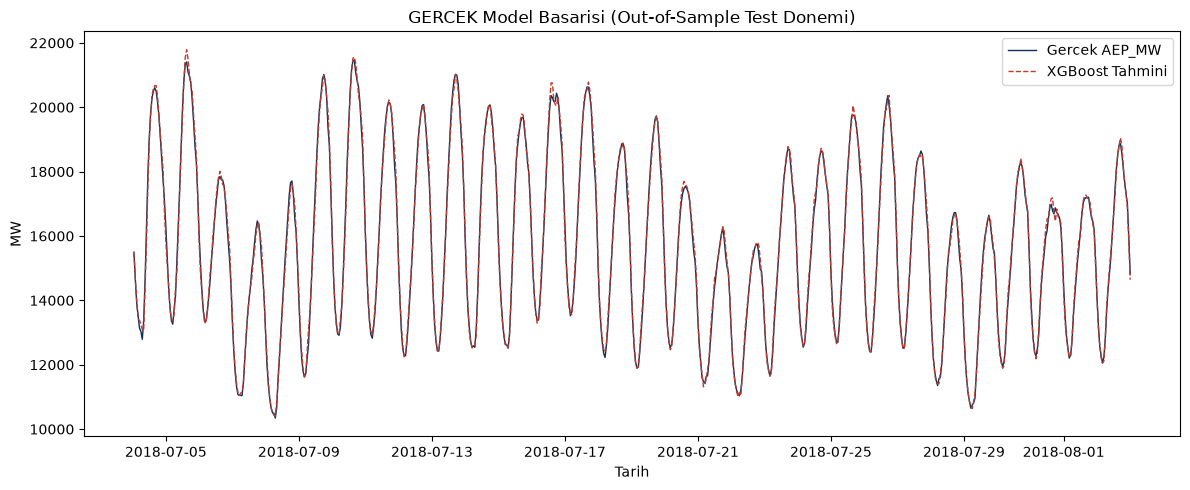

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(xgb_test["Datetime"], y_test.values, label="Gercek AEP_MW", color="#0F3057", linewidth=1)
ax.plot(xgb_test["Datetime"], xgb_pred, label="XGBoost Tahmini", color="#C0392B", linewidth=1, linestyle="--")
ax.set_title("GERCEK Model Basarisi (Out-of-Sample Test Donemi)")
ax.set_xlabel("Tarih")
ax.set_ylabel("MW")
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\viz_xgboost_test_period_actual_vs_pred.png", dpi=150)
plt.show()


## Saat Bazlı Hata Deseni

In [12]:
xgb_test_results = xgb_test.copy()
xgb_test_results["actual"] = y_test.values
xgb_test_results["predicted"] = xgb_pred
xgb_test_results["error_pct"] = (xgb_test_results["actual"] - xgb_test_results["predicted"]) / xgb_test_results["actual"]

hourly_error_xgb = xgb_test_results.groupby("hour")["error_pct"].apply(lambda x: x.abs().mean())
print("XGBoost saat bazli hata:")
print(hourly_error_xgb.sort_values())
print(f"\nEn isabetli saat: {hourly_error_xgb.idxmin()}:00 (%{hourly_error_xgb.min()*100:.2f})")
print(f"En yuksek hata: {hourly_error_xgb.idxmax()}:00 (%{hourly_error_xgb.max()*100:.2f})")

XGBoost saat bazli hata:
hour
4     0.003891
3     0.004408
18    0.005122
17    0.005494
5     0.005533
23    0.005598
19    0.005601
15    0.006226
16    0.006370
2     0.006825
13    0.006960
9     0.006990
14    0.007095
20    0.007300
1     0.007483
11    0.007651
0     0.008133
6     0.008230
12    0.008745
10    0.009525
8     0.010272
22    0.010340
7     0.011488
21    0.015227
Name: error_pct, dtype: float64

En isabetli saat: 4:00 (%0.39)
En yuksek hata: 21:00 (%1.52)


## Hata Sebepleri

In [13]:
# "Rampa saati" hipotezini kendi verimizle dogrudan test ediyoruz
df_sorted = df.sort_values("Datetime").reset_index(drop=True)

# 1) Her saatin KENDI seviyesindeki degiskenlik (std/mean = Coefficient of Variation)
hourly_stats = df_sorted.groupby("hour")["AEP_MW"].agg(["mean", "std"])
hourly_stats["cv_pct"] = (hourly_stats["std"] / hourly_stats["mean"]) * 100

# 2) O saate GECISIN buyuklugunun gun-gun degiskenligi (asil "rampa" testi)
df_sorted["hourly_change"] = df_sorted["AEP_MW"].diff()
change_by_hour = df_sorted.dropna(subset=["hourly_change"]).groupby("hour")["hourly_change"].std()
hourly_stats["ramp_volatility_mw"] = change_by_hour

print("=== Saat bazli seviye degiskenligi (CV%), en yuksekten en dusuge ===")
print(hourly_stats.sort_values("cv_pct", ascending=False)["cv_pct"].round(2))

print("\n=== Saate GECISIN buyuklugunun degiskenligi (MW), en yuksekten en dusuge ===")
print(hourly_stats.sort_values("ramp_volatility_mw", ascending=False)["ramp_volatility_mw"].round(1))

print(f"\n07:00 -> CV: %{hourly_stats.loc[7,'cv_pct']:.2f}  |  Gecis degiskenligi: {hourly_stats.loc[7,'ramp_volatility_mw']:.1f} MW")
print(f"21:00 -> CV: %{hourly_stats.loc[21,'cv_pct']:.2f}  |  Gecis degiskenligi: {hourly_stats.loc[21,'ramp_volatility_mw']:.1f} MW")
print(f"Ortalama (tum saatler) gecis degiskenligi: {hourly_stats['ramp_volatility_mw'].mean():.1f} MW")

=== Saat bazli seviye degiskenligi (CV%), en yuksekten en dusuge ===
hour
7     16.77
8     16.61
6     16.00
5     15.71
4     15.33
17    15.29
16    15.22
18    14.99
3     14.86
9     14.84
15    14.77
19    14.71
2     14.31
14    14.08
20    13.77
1     13.66
10    13.36
13    13.29
0     13.12
23    12.83
12    12.78
21    12.77
11    12.74
22    12.71
Name: cv_pct, dtype: float64

=== Saate GECISIN buyuklugunun degiskenligi (MW), en yuksekten en dusuge ===
hour
7     532.6
11    497.7
12    475.9
10    469.5
18    435.7
19    434.5
13    420.0
9     413.4
20    399.0
14    381.2
21    373.6
15    313.5
0     313.5
6     298.9
1     290.9
23    263.1
22    259.3
2     238.6
8     231.3
16    211.0
3     197.6
5     180.2
17    177.7
4     169.8
Name: ramp_volatility_mw, dtype: float64

07:00 -> CV: %16.77  |  Gecis degiskenligi: 532.6 MW
21:00 -> CV: %12.77  |  Gecis degiskenligi: 373.6 MW
Ortalama (tum saatler) gecis degiskenligi: 332.4 MW


### Adım 13 — Walk-Forward Validation (Aylık GERÇEK Out-of-Sample Tahminler)

**Metodolojik not:** İlk yaklaşımımız (eğitim verisi üzerinde "in-sample" tahmin üretmek) yanıltıcı olabileceği için terk edildi (kaynak: arXiv:2006.15069, overfitting bölümü — eğitim verisi üzerindeki performans gerçek tahmin başarısını yapay olarak yüksek gösterebilir). Bunun yerine **Walk-Forward Validation** kullanılıyor — MachineLearningMastery'nin kendi ifadesiyle *"zaman serisi dünyasının k-fold cross-validation'ı, altın standart"*. Her ay için, **o aydan önceki tüm veriyle** model yeniden eğitilip sadece **bir sonraki ay** tahmin ediliyor — bu, gerçek, sahte olmayan bir out-of-sample tahmindir.

**Kapsam:** 2005-2006, modelin en az bir tam yıllık döngü görmesi için gereken minimum başlangıç penceresi olarak ayrılmıştır (bu iki yıl için tahmin üretilmez — walk-forward validation'ın kendi standart gerekliliği). 2007-2016 arası **120 ay** için gerçek tahmin üretilir.

**Süre uyarısı:** Bu hücre, 120 ayrı XGBoost eğitimi çalıştırır — LSTM'in aksine XGBoost saniyeler içinde eğitildiği için toplam süre birkaç dakika ile sınırlı kalır.

In [14]:
walk_forward_start = pd.Timestamp("2007-01-01")
walk_forward_end = pd.Timestamp("2017-01-01")

results = []
current = walk_forward_start

while current < walk_forward_end:
    month_end = current + pd.DateOffset(months=1)

    wf_train = xgb_df[xgb_df["Datetime"] < current]
    wf_test = xgb_df[(xgb_df["Datetime"] >= current) & (xgb_df["Datetime"] < month_end)]

    if wf_test.empty:
        current = month_end
        continue

    wf_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
    wf_model.fit(wf_train[xgb_features], wf_train["AEP_MW"])
    wf_pred = wf_model.predict(wf_test[xgb_features])

    results.append({
        "year": current.year, "month": current.month,
        "datetime": wf_test["Datetime"].values,
        "actual": wf_test["AEP_MW"].values,
        "predicted": wf_pred,
    })
    print(f"{current.year}-{current.month:02d} tamamlandi ({len(wf_test)} saat, GERCEK out-of-sample)")
    current = month_end

print(f"\nToplam {len(results)} ay, walk-forward validation ile GERCEK tahmin uretildi")


2007-01 tamamlandi (744 saat, GERCEK out-of-sample)
2007-02 tamamlandi (672 saat, GERCEK out-of-sample)
2007-03 tamamlandi (743 saat, GERCEK out-of-sample)
2007-04 tamamlandi (720 saat, GERCEK out-of-sample)
2007-05 tamamlandi (744 saat, GERCEK out-of-sample)
2007-06 tamamlandi (720 saat, GERCEK out-of-sample)
2007-07 tamamlandi (744 saat, GERCEK out-of-sample)
2007-08 tamamlandi (744 saat, GERCEK out-of-sample)
2007-09 tamamlandi (720 saat, GERCEK out-of-sample)
2007-10 tamamlandi (744 saat, GERCEK out-of-sample)
2007-11 tamamlandi (719 saat, GERCEK out-of-sample)
2007-12 tamamlandi (744 saat, GERCEK out-of-sample)
2008-01 tamamlandi (744 saat, GERCEK out-of-sample)
2008-02 tamamlandi (696 saat, GERCEK out-of-sample)
2008-03 tamamlandi (743 saat, GERCEK out-of-sample)
2008-04 tamamlandi (720 saat, GERCEK out-of-sample)
2008-05 tamamlandi (720 saat, GERCEK out-of-sample)
2008-06 tamamlandi (720 saat, GERCEK out-of-sample)
2008-07 tamamlandi (744 saat, GERCEK out-of-sample)
2008-08 tama

### Adım 14 — Walk-Forward Grafiklerini Üretin ve Kaydedin

In [15]:
import calendar, os

yearly_dir = r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\trend\Yearly_XGBoost"

for r in results:
    month_name = calendar.month_name[r["month"]]
    month_dir = f"{yearly_dir}\\{r['year']}\\{month_name}"
    os.makedirs(month_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(r["datetime"], r["actual"], color="#0F3057", linewidth=0.8, label="Gercek")
    ax.plot(r["datetime"], r["predicted"], color="#1B98A4", linewidth=0.8, alpha=0.8, label="XGBoost (Walk-Forward, GERCEK Tahmin)")
    ax.set_title(f"XGBoost Walk-Forward Tahmini - {month_name} {r['year']}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{month_dir}\\walk_forward_prediction.png", dpi=100)
    plt.close(fig)

print("Grafikler kaydedildi:", yearly_dir)
print(f"Toplam {len(results)} grafik uretildi (2007-2016, aylik gercek out-of-sample tahmin)")


Grafikler kaydedildi: C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\trend\Yearly_XGBoost
Toplam 120 grafik uretildi (2007-2016, aylik gercek out-of-sample tahmin)


## Modeli Kaydetme

In [16]:
xgb_model.save_model(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\agent\grid_xgb_model.json")

## Gerçek Zirve

In [17]:
# 2005'in GERCEK zirvesini "planlama referansi" olarak sabitleyip,
# SONRAKI tum yillarin gercek talebini buna karsi test ediyoruz
df_sorted = df.sort_values("Datetime").reset_index(drop=True)

baseline_year_peak = df_sorted[df_sorted["Datetime"].dt.year == 2005]["AEP_MW"].max()
fixed_planning_capacity = baseline_year_peak * 1.20

print(f"2005 gercek zirvesi: {baseline_year_peak:.0f} MW")
print(f"Sabit planlama kapasitesi (x1,20): {fixed_planning_capacity:.0f} MW")

# Bu sabit kapasiteyi asan TUM gercek saatleri bul (2006 sonrasi)
breach_df = df_sorted[(df_sorted["Datetime"].dt.year > 2005) & (df_sorted["AEP_MW"] > fixed_planning_capacity)]
print(f"\n2006 sonrasi, bu sabit kapasiteyi asan saat sayisi: {len(breach_df)}")

if len(breach_df) > 0:
    first_breach = breach_df.sort_values("Datetime").iloc[0]
    margin_pct = (fixed_planning_capacity - first_breach["AEP_MW"]) / fixed_planning_capacity * 100
    print(f"\nILK ESIK ASIMI (gercek veri):")
    print(f"  Tarih: {first_breach['Datetime']}")
    print(f"  Gercek talep: {first_breach['AEP_MW']:.0f} MW")
    print(f"  Sabit kapasite: {fixed_planning_capacity:.0f} MW")
    print(f"  Marj: %{margin_pct:.1f} (NEGATIF = asim)")

2005 gercek zirvesi: 24015 MW
Sabit planlama kapasitesi (x1,20): 28818 MW

2006 sonrasi, bu sabit kapasiteyi asan saat sayisi: 0


In [18]:
overall_max = df_sorted["AEP_MW"].max()
overall_max_date = df_sorted.loc[df_sorted["AEP_MW"].idxmax(), "Datetime"]
print(f"14 yilin MUTLAK zirvesi: {overall_max:.0f} MW, tarih: {overall_max_date}")
print(f"2005 zirvesi bunun %{2005 and (24015/overall_max*100):.1f}'i")

14 yilin MUTLAK zirvesi: 25695 MW, tarih: 2008-10-20 14:00:00
2005 zirvesi bunun %93.5'i


## XGBoost Ablasyon Testi

In [19]:
# ============================================================
# ABLASYON TESTI: lag_1'i cikarip modeli yeniden egitiyoruz
# Hipotez: 21:00'deki hata sicramasi, lag_1'in asiri agirligindan
# kaynaklaniyorsa, lag_1 cikarilinca bu sicrama kaybolmali/kuculmeli
# ============================================================

# lag_1 HARIC, ayni ozellik seti
xgb_features_no_lag1 = [f for f in xgb_features if f != "lag_1"]
print("Ablasyon ozellik seti:", xgb_features_no_lag1)

X_train_ablation = xgb_train[xgb_features_no_lag1]
X_test_ablation = xgb_test[xgb_features_no_lag1]

# Ayni hiperparametrelerle, sadece lag_1 olmadan yeniden egitim
xgb_model_ablation = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, early_stopping_rounds=20
)
xgb_model_ablation.fit(
    X_train_ablation, y_train,
    eval_set=[(X_test_ablation, y_test)], verbose=False
)
xgb_pred_ablation = xgb_model_ablation.predict(X_test_ablation)

# Genel RMSPE karsilastirmasi
xgb_rmspe_ablation = rmspe(y_test.values, xgb_pred_ablation)
print(f"\nOrijinal XGBoost RMSPE (lag_1 DAHIL): {xgb_rmspe:.4f}")
print(f"Ablasyon XGBoost RMSPE (lag_1 HARIC): {xgb_rmspe_ablation:.4f}")

# ASIL TEST: saat bazli hata - 21:00'e ne oldu?
xgb_test_results_ablation = xgb_test.copy()
xgb_test_results_ablation["actual"] = y_test.values
xgb_test_results_ablation["predicted"] = xgb_pred_ablation
xgb_test_results_ablation["error_pct"] = (
    (xgb_test_results_ablation["actual"] - xgb_test_results_ablation["predicted"])
    / xgb_test_results_ablation["actual"]
)
hourly_error_ablation = xgb_test_results_ablation.groupby("hour")["error_pct"].apply(lambda x: x.abs().mean())

print("\n=== KARSILASTIRMA: Saat 21:00 hatasi ===")
print(f"Orijinal (lag_1 DAHIL):  %{hourly_error_xgb[21]*100:.2f}")
print(f"Ablasyon (lag_1 HARIC):  %{hourly_error_ablation[21]*100:.2f}")

print("\n=== Ablasyon sonrasi TUM saatlerin hatasi ===")
print(hourly_error_ablation.sort_values())
print(f"\nAblasyon sonrasi en yuksek hata saati: {hourly_error_ablation.idxmax()}:00 (%{hourly_error_ablation.max()*100:.2f})")

Ablasyon ozellik seti: ['hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'avg_temp_f', 'HDD', 'CDD', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'rolling_24h_mean']

Orijinal XGBoost RMSPE (lag_1 DAHIL): 0.0097
Ablasyon XGBoost RMSPE (lag_1 HARIC): 0.0183

=== KARSILASTIRMA: Saat 21:00 hatasi ===
Orijinal (lag_1 DAHIL):  %1.52
Ablasyon (lag_1 HARIC):  %2.06

=== Ablasyon sonrasi TUM saatlerin hatasi ===
hour
4     0.007759
5     0.007884
3     0.009481
6     0.010058
19    0.010844
18    0.012050
2     0.012293
1     0.012739
0     0.012980
20    0.013031
14    0.013800
16    0.014191
9     0.014197
17    0.014686
13    0.014973
15    0.015189
10    0.015434
12    0.016354
11    0.017167
23    0.017179
8     0.017628
7     0.018477
21    0.020635
22    0.022286
Name: error_pct, dtype: float64

Ablasyon sonrasi en yuksek hata saati: 22:00 (%2.23)


## Ablasyon Testi Devam

=== lag_1 / lag_2 / lag_24, 'hour' ile etkilesimi ===

lag_1 x hour etkilesimi:
  Saat=21'de ortalama etki: -77.07 MW
  Saat=22'de ortalama etki: -33.15 MW
  Tum saatlerde ortalama etki: -38.95 MW

lag_2 x hour etkilesimi:
  Saat=21'de ortalama etki: +9.31 MW
  Saat=22'de ortalama etki: +15.13 MW
  Tum saatlerde ortalama etki: +4.15 MW

lag_24 x hour etkilesimi:
  Saat=21'de ortalama etki: +0.35 MW
  Saat=22'de ortalama etki: +7.03 MW
  Tum saatlerde ortalama etki: +0.22 MW



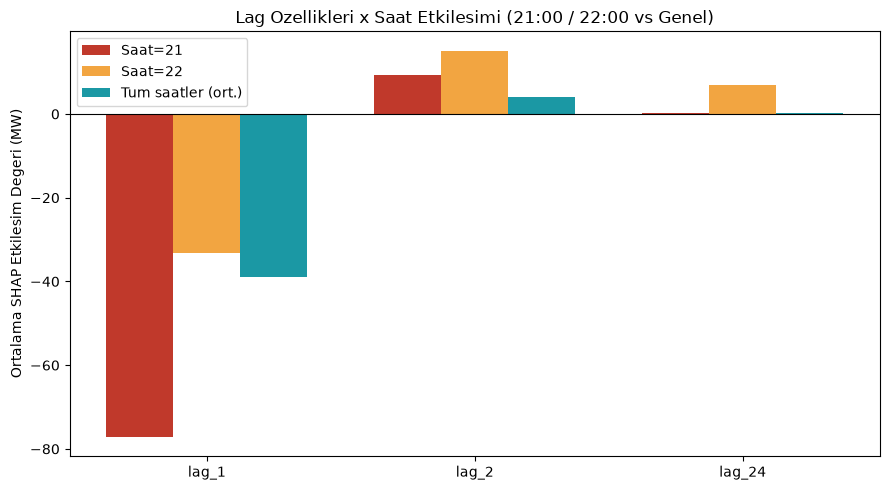

In [20]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Orijinal (lag_1 DAHIL) model uzerinde SHAP Etkilesim Degerleri
# Not: TreeExplainer, ablasyon modelini degil, asil uretim modelini (xgb_model) kullanir
explainer = shap.TreeExplainer(xgb_model)
shap_interaction = explainer.shap_interaction_values(X_test)
# sekil: (n_ornek, n_ozellik, n_ozellik)

feature_names = xgb_features
hour_idx = feature_names.index("hour")

hour_21_mask = (X_test["hour"] == 21).values
hour_22_mask = (X_test["hour"] == 22).values

print("=== lag_1 / lag_2 / lag_24, 'hour' ile etkilesimi ===\n")
results = {}
for lag_feature in ["lag_1", "lag_2", "lag_24"]:
    lag_idx = feature_names.index(lag_feature)

    interaction_21 = shap_interaction[hour_21_mask, lag_idx, hour_idx]
    interaction_22 = shap_interaction[hour_22_mask, lag_idx, hour_idx]
    interaction_all = shap_interaction[:, lag_idx, hour_idx]

    results[lag_feature] = {"h21": interaction_21.mean(), "h22": interaction_22.mean(), "all": interaction_all.mean()}

    print(f"{lag_feature} x hour etkilesimi:")
    print(f"  Saat=21'de ortalama etki: {interaction_21.mean():+.2f} MW")
    print(f"  Saat=22'de ortalama etki: {interaction_22.mean():+.2f} MW")
    print(f"  Tum saatlerde ortalama etki: {interaction_all.mean():+.2f} MW")
    print()

# Gorsellestirme
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
width = 0.25
labels = ["lag_1", "lag_2", "lag_24"]
h21_vals = [results[f]["h21"] for f in labels]
h22_vals = [results[f]["h22"] for f in labels]
all_vals = [results[f]["all"] for f in labels]

ax.bar(x - width, h21_vals, width, label="Saat=21", color="#C0392B")
ax.bar(x, h22_vals, width, label="Saat=22", color="#F2A541")
ax.bar(x + width, all_vals, width, label="Tum saatler (ort.)", color="#1B98A4")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Ortalama SHAP Etkilesim Degeri (MW)")
ax.set_title("Lag Ozellikleri x Saat Etkilesimi (21:00 / 22:00 vs Genel)")
ax.legend()
plt.tight_layout()
plt.savefig(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\viz_shap_interaction_21_22.png", dpi=150)
plt.show()

In [21]:
df.groupby("hour")["AEP_MW"].mean().sort_values(ascending=False).head(5)

hour
19    16868.728334
20    16821.335180
21    16763.806292
18    16762.940047
17    16542.038781
Name: AEP_MW, dtype: float64

In [22]:
xgb_test_results[xgb_test_results["hour"] == 21][["actual", "predicted"]].describe()

,actual,predicted
count,30.000000,30.000000
mean,17357.200000,17614.472656
std,1396.063046,1428.180786
min,14975.000000,15208.062500
25%,16481.750000,16420.484619
50%,17433.500000,17677.914062
75%,18349.750000,18706.646973
max,19411.000000,19885.435547


## MW ve Hata oranı

In [23]:
# 24 saatin TAMAMI icin ortalama gercek MW (LSTM/1.ipynb ve XGBoost/2.ipynb icin ayni mantik)
hourly_mw = df.groupby("hour")["AEP_MW"].mean().sort_index()
print("24 saatin tamami, MW:")
print(hourly_mw.round(0))

24 saatin tamami, MW:
hour
0     14651.0
1     13891.0
2     13432.0
3     13184.0
4     13095.0
5     13241.0
6     13802.0
7     14782.0
8     15479.0
9     15823.0
10    16084.0
11    16306.0
12    16398.0
13    16478.0
14    16535.0
15    16493.0
16    16445.0
17    16542.0
18    16763.0
19    16869.0
20    16821.0
21    16764.0
22    16469.0
23    15633.0
Name: AEP_MW, dtype: float64


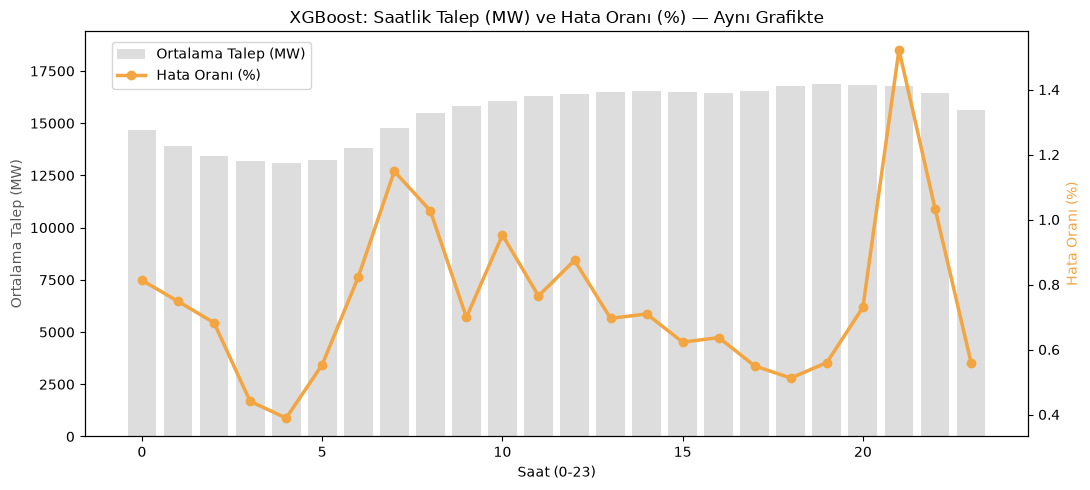

In [24]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.bar(hourly_mw.index, hourly_mw.values, color="#CFCFCF", alpha=0.7, label="Ortalama Talep (MW)")
ax1.set_xlabel("Saat (0-23)")
ax1.set_ylabel("Ortalama Talep (MW)", color="#595959")
ax1.set_ylim(0, hourly_mw.max() * 1.15)  # sifirdan basliyor - dogru pratik

ax2 = ax1.twinx()
ax2.plot(hourly_error_xgb.index, hourly_error_xgb.values * 100, color="#F2A541", linewidth=2.5, marker="o", label="Hata Oranı (%)")
ax2.set_ylabel("Hata Oranı (%)", color="#F2A541")

ax1.set_title("XGBoost: Saatlik Talep (MW) ve Hata Oranı (%) — Aynı Grafikte")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.92))
plt.tight_layout()
plt.savefig(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\viz_xgboost_mw_vs_error.png", dpi=150)
plt.show()